# Mobilidade Urbana e Transporte Público no Brasil (2015–2024)
**Avaliação G1 — Linguagem de Programação: Análise e Visualização de Dados com Python Professor:Alexandre Louzada**

## 1. Introdução
A mobilidade urbana afeta a qualidade de vida, a produtividade e o meio ambiente nas cidades brasileiras. Neste notebook analisamos uma base **simulada** de mobilidade urbana para responder às perguntas orientadoras do projeto:

1. Quais cidades têm maior fluxo de passageiros?
2. Qual meio de transporte é mais utilizado?
3. O tempo médio de deslocamento aumentou ao longo do tempo?
4. Existem diferenças regionais relevantes?
5. Há relação entre população e fluxo de transporte?
6. Quais regiões sofrem maior pressão sobre o sistema?
7. Quais horários apresentam maior congestionamento?

> As perguntas 5 e 7 dependem de dados que a base não possui (população e horário). Elas são discutidas na seção de limitações.

## 2. Contextualização da mobilidade urbana
O crescimento das cidades aumenta a demanda por transporte coletivo. Quando a oferta não acompanha essa demanda, aparecem veículos lotados, viagens mais longas, vias congestionadas e mais emissões de poluentes. Monitorar indicadores como **passageiros, tempo de deslocamento, lotação, velocidade e tarifa** ajuda a identificar gargalos e comparar regiões e meios de transporte.

## 3. Explicação da base de dados
Arquivo: `dados/simulacao_mobilidade_urbana_brasil.csv`. Cada linha é uma combinação **cidade × mês** (jan/2015 a dez/2024) com um meio de transporte.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período da medição |
| regiao, uf, cidade | Localização |
| meio_transporte | Ônibus, Metrô, Trem, BRT, VLT ou Bicicleta |
| passageiros | Quantidade de passageiros |
| tempo_medio_deslocamento | Minutos |
| lotacao_media | Percentual médio de lotação |
| velocidade_media | Velocidade média do sistema (km/h, suposição) |
| emissao_co2 | Emissão estimada (sem unidade na base) |
| tarifa_media | Valor médio da tarifa (R$, suposição) |
| nivel_congestionamento | Baixo, Médio, Alto ou Crítico |

## 4. Leitura dos dados

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
RAIZ = Path("..")
IMG = RAIZ / "imagens"
IMG.mkdir(exist_ok=True)

df = pd.read_csv(RAIZ / "dados" / "simulacao_mobilidade_urbana_brasil.csv")
print(df.shape)
df.head()

(4440, 14)


,ano,mes,data,regiao,uf,cidade,meio_transporte,passageiros,tempo_medio_deslocamento,lotacao_media,velocidade_media,emissao_co2,tarifa_media,nivel_congestionamento
0,2015,1,2015-01-01,Norte,AM,Manaus,Ônibus,1755471,53.2,93.1,11.4,12843.56,4.32,Crítico
1,2015,1,2015-01-01,Norte,PA,Belém,Bicicleta,1998552,59.8,30.2,42.9,47909.46,7.13,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,BRT,898998,85.6,85.2,18.1,4920.12,4.19,Crítico
3,2015,1,2015-01-01,Norte,RO,Porto Velho,VLT,1915833,63.2,49.3,23.6,15029.32,7.62,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,Metrô,607152,81.8,83.9,19.9,39672.18,7.03,Médio


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ano                       4440 non-null   int64  
 1   mes                       4440 non-null   int64  
 2   data                      4440 non-null   str    
 3   regiao                    4440 non-null   str    
 4   uf                        4440 non-null   str    
 5   cidade                    4440 non-null   str    
 6   meio_transporte           4440 non-null   str    
 7   passageiros               4440 non-null   int64  
 8   tempo_medio_deslocamento  4440 non-null   float64
 9   lotacao_media             4440 non-null   float64
 10  velocidade_media          4440 non-null   float64
 11  emissao_co2               4440 non-null   float64
 12  tarifa_media              4440 non-null   float64
 13  nivel_congestionamento    4440 non-null   str    
dtypes: float64(5), int6

In [3]:
display(df.describe().T.round(2))
print("Valores nulos:", int(df.isna().sum().sum()), "| Linhas duplicadas:", int(df.duplicated().sum()))

,count,mean,std,min,25%,50%,75%,max
ano,4440.0,2019.50,2.87,2015.0,2017.00,2019.50,2022.00,2024.00
mes,4440.0,6.50,3.45,1.0,3.75,6.50,9.25,12.00
passageiros,4440.0,1002671.88,581473.25,10476.0,493984.75,1000033.00,1502804.50,1998580.00
tempo_medio_deslocamento,4440.0,54.28,22.94,15.0,34.70,53.80,73.93,94.90
lotacao_media,4440.0,70.33,28.76,20.0,45.10,71.00,95.10,120.00
velocidade_media,4440.0,31.54,13.55,8.0,19.90,31.60,43.20,55.00
emissao_co2,4440.0,24942.18,14414.25,41.9,12366.59,24578.50,37415.96,49999.26
tarifa_media,4440.0,5.76,1.29,3.5,4.65,5.76,6.85,8.00


Valores nulos: 0 | Linhas duplicadas: 0


## 5. Limpeza e preparação
Passos aplicados (as mesmas regras de `utils.tratar_dados`, usada no dashboard):
- remover espaços extras em textos e converter `data` para datetime;
- remover duplicatas e nulos;
- checar a coerência entre `ano`/`mes` e `data`;
- descartar valores impossíveis (passageiros ou tempo ≤ 0);
- tornar `nivel_congestionamento` uma variável categórica **ordenada** (Baixo < Médio < Alto < Crítico).

In [4]:
ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]
NUM = {n: i + 1 for i, n in enumerate(ORDEM)}
MESES = {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"}

antes = len(df)
for c in ["regiao", "uf", "cidade", "meio_transporte", "nivel_congestionamento"]:
    df[c] = df[c].astype(str).str.strip()
df["data"] = pd.to_datetime(df["data"], errors="coerce")
df = df.drop_duplicates().dropna()
df = df[(df["data"].dt.year == df["ano"]) & (df["data"].dt.month == df["mes"])]
df = df[(df["passageiros"] > 0) & (df["tempo_medio_deslocamento"] > 0)]
df["nivel_num"] = df["nivel_congestionamento"].map(NUM).astype(int)
df["nivel_congestionamento"] = pd.Categorical(df["nivel_congestionamento"], categories=ORDEM, ordered=True)
df = df.reset_index(drop=True)
print(f"Linhas antes: {antes} | depois: {len(df)} | removidas: {antes - len(df)}")

Linhas antes: 4440 | depois: 4440 | removidas: 0


In [5]:
# Verificação de outliers (regra do IQR) nas variáveis numéricas
num = ["passageiros", "tempo_medio_deslocamento", "lotacao_media", "velocidade_media", "emissao_co2", "tarifa_media"]
linhas = []
for c in num:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    linhas.append((c, int(((df[c] < q1 - 1.5*iqr) | (df[c] > q3 + 1.5*iqr)).sum())))
print(pd.DataFrame(linhas, columns=["variavel", "outliers_IQR"]).to_string(index=False))
print("\nRegistros com lotação > 100%:", int((df["lotacao_media"] > 100).sum()),
      "(mantidos: indicam superlotação, não erro)")

                variavel  outliers_IQR
             passageiros             0
tempo_medio_deslocamento             0
           lotacao_media             0
        velocidade_media             0
             emissao_co2             0
            tarifa_media             0

Registros com lotação > 100%: 885 (mantidos: indicam superlotação, não erro)


## 6. Engenharia de atributos
Criamos variáveis derivadas para enriquecer a análise:
- `nivel_num`: congestionamento em escala de 1 a 4;
- `superlotacao`: lotação acima de 100%;
- `indice_pressao`: média entre a lotação (relativa a 120%) e o congestionamento (relativo a 4), valor de 0 a 1;
- `co2_por_mil_pass`: emissão por mil passageiros (permite comparar modais de tamanhos diferentes);
- `mes_nome` e `trimestre`.

In [6]:
df["mes_nome"] = df["mes"].map(MESES)
df["trimestre"] = df["data"].dt.quarter
df["superlotacao"] = df["lotacao_media"] > 100
df["indice_pressao"] = (df["lotacao_media"].clip(upper=120) / 120 + df["nivel_num"] / 4) / 2
df["co2_por_mil_pass"] = df["emissao_co2"] / (df["passageiros"] / 1000)
df[["cidade", "nivel_num", "superlotacao", "indice_pressao", "co2_por_mil_pass"]].head()

,cidade,nivel_num,superlotacao,indice_pressao,co2_por_mil_pass
0,Manaus,4,False,0.887917,7.316304
1,Belém,2,False,0.375833,23.972086
2,Santarém,4,False,0.855000,5.472893
3,Porto Velho,2,False,0.455417,7.844796
4,Palmas,2,False,0.599583,65.341430


## 7. Análise exploratória

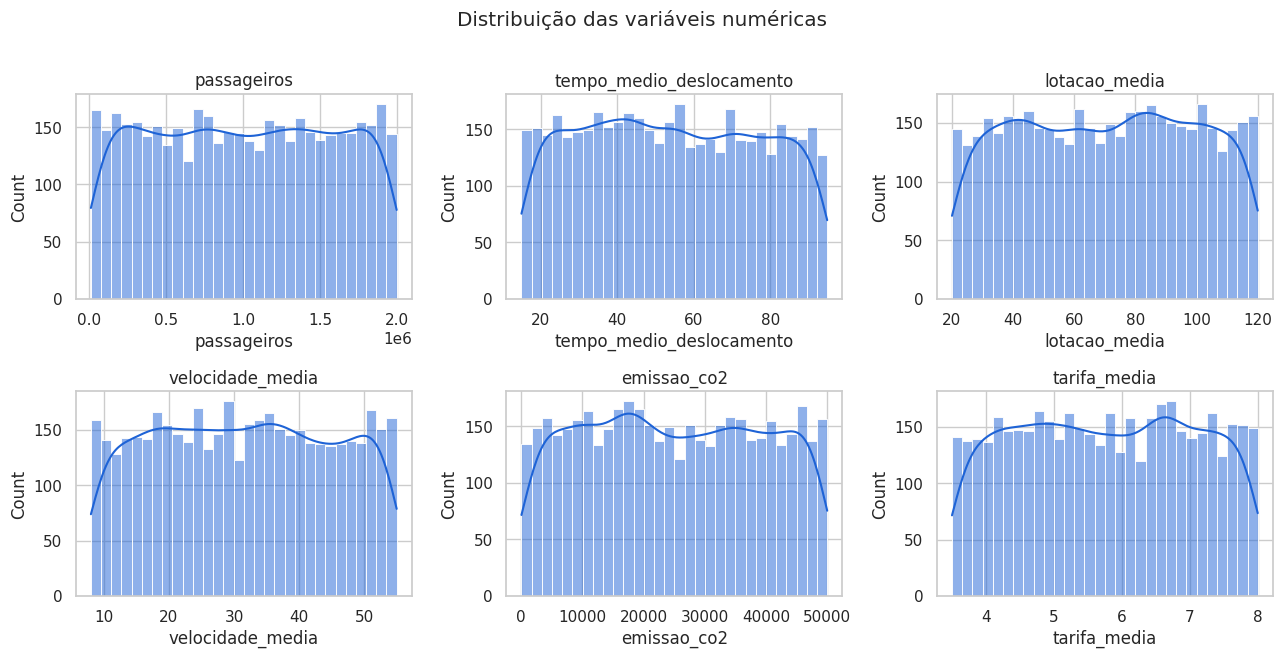

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, c in zip(axes.ravel(), num):
    sns.histplot(df[c], bins=30, kde=True, ax=ax, color="#1E63D6")
    ax.set_title(c)
fig.suptitle("Distribuição das variáveis numéricas", y=1.01)
fig.tight_layout(); fig.savefig(IMG / "01_distribuicoes.png", dpi=130, bbox_inches="tight"); plt.show()

In [8]:
print("Registros por região:"); display(df["regiao"].value_counts().to_frame("registros").T)
print("Cidades por região:"); display(df.groupby("regiao")["cidade"].nunique().to_frame("cidades").T)
print("Registros por meio de transporte:"); display(df["meio_transporte"].value_counts().to_frame("registros").T)
print("Registros por nível de congestionamento:"); display(df["nivel_congestionamento"].value_counts().reindex(ORDEM).to_frame("registros").T)

Registros por região:


regiao,Sudeste,Nordeste,Sul,Norte,Centro-Oeste
registros,1560,960,720,600,600


Cidades por região:


regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
cidades,5,8,5,13,6


Registros por meio de transporte:


meio_transporte,BRT,VLT,Metrô,Bicicleta,Trem,Ônibus
registros,777,745,745,734,728,711


Registros por nível de congestionamento:


nivel_congestionamento,Baixo,Médio,Alto,Crítico
registros,1118,1178,1099,1045


**Leitura da exploração:** as variáveis numéricas têm distribuição aproximadamente **uniforme** (histogramas retangulares), sem outliers pelo critério do IQR. Isso é característico de dados gerados por sorteio, e não de dados reais, que costumam ser assimétricos. A quantidade de cidades varia por região (o Sudeste tem mais), o que afeta totais brutos.

## 8. KPIs

In [9]:
por_cidade = df.groupby("cidade")["passageiros"].sum()
por_modal = df.groupby("meio_transporte")["passageiros"].sum()
nivel_medio = df["nivel_num"].mean()
kpis = {
    "Total de passageiros": f"{df['passageiros'].sum():,.0f}".replace(",", "."),
    "Cidade mais movimentada": f"{por_cidade.idxmax()} ({por_cidade.max()/1e6:.1f} mi)",
    "Meio de transporte predominante": f"{por_modal.idxmax()} ({por_modal.max()/por_modal.sum():.1%})",
    "Tempo médio de deslocamento": f"{df['tempo_medio_deslocamento'].mean():.1f} min",
    "Tarifa média": f"R$ {df['tarifa_media'].mean():.2f}",
    "Nível médio de congestionamento": f"{ORDEM[int(nivel_medio + .5) - 1]} ({nivel_medio:.2f} de 4)",
}
pd.Series(kpis, name="Valor").to_frame()

,Valor
Total de passageiros,4.451.863.133
Cidade mais movimentada,Rio de Janeiro (131.1 mi)
Meio de transporte predominante,Metrô (17.5%)
Tempo médio de deslocamento,54.3 min
Tarifa média,R$ 5.76
Nível médio de congestionamento,Médio (2.47 de 4)


## 9. Visualizações

### 9.1 Evolução temporal

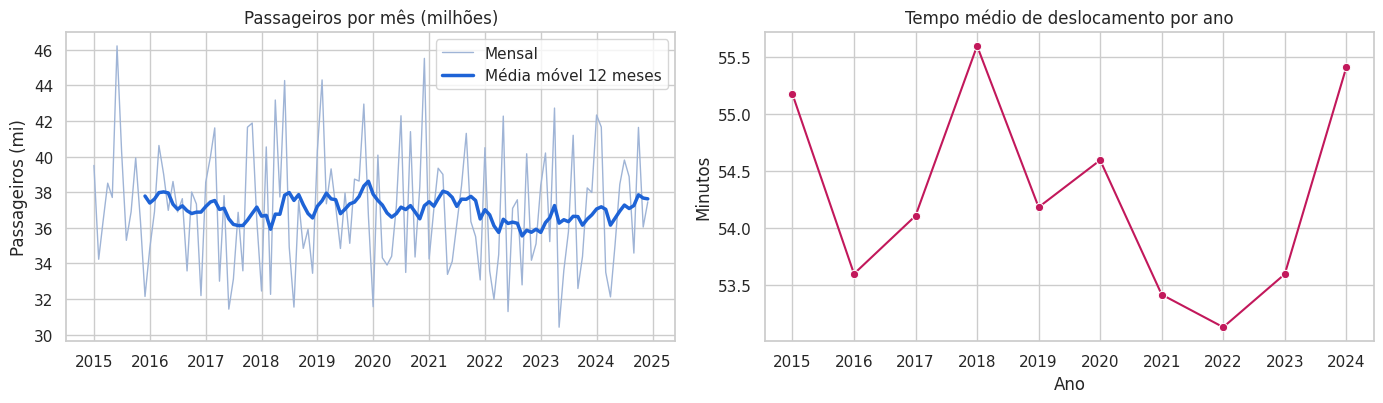

In [10]:
mensal = df.groupby("data")["passageiros"].sum() / 1e6
anual = df.groupby("ano")["tempo_medio_deslocamento"].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
sns.lineplot(x=mensal.index, y=mensal.values, ax=axes[0], color="#9FB4D6", lw=1, label="Mensal")
sns.lineplot(x=mensal.index, y=mensal.rolling(12).mean().values, ax=axes[0], color="#1E63D6", lw=2.5, label="Média móvel 12 meses")
axes[0].set(title="Passageiros por mês (milhões)", xlabel="", ylabel="Passageiros (mi)")
sns.lineplot(data=anual, x="ano", y="tempo_medio_deslocamento", marker="o", color="#C2185B", ax=axes[1])
axes[1].set(title="Tempo médio de deslocamento por ano", xlabel="Ano", ylabel="Minutos"); axes[1].set_xticks(anual["ano"])
fig.tight_layout(); fig.savefig(IMG / "02_evolucao_temporal.png", dpi=130, bbox_inches="tight"); plt.show()

### 9.2 Comparação entre cidades e regiões

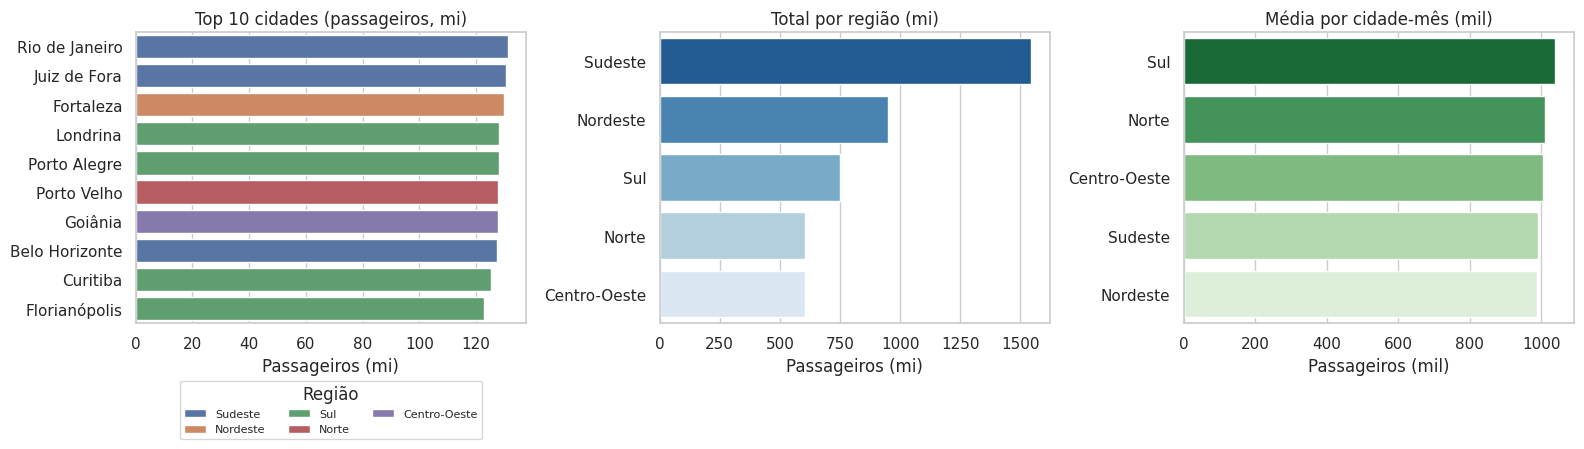

In [11]:
cid = df.groupby(["cidade", "regiao"])["passageiros"].sum().reset_index().nlargest(10, "passageiros")
reg = df.groupby("regiao").agg(total=("passageiros", "sum"), media=("passageiros", "mean")).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.barplot(data=cid, y="cidade", x=cid["passageiros"]/1e6, hue="regiao", dodge=False, ax=axes[0])
axes[0].set(title="Top 10 cidades (passageiros, mi)", xlabel="Passageiros (mi)", ylabel="")
axes[0].legend(title="Região", fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
r1 = reg.sort_values("total", ascending=False)
sns.barplot(data=r1, y="regiao", x=r1["total"]/1e6, hue="regiao", legend=False, palette="Blues_r", ax=axes[1])
axes[1].set(title="Total por região (mi)", xlabel="Passageiros (mi)", ylabel="")
r2 = reg.sort_values("media", ascending=False)
sns.barplot(data=r2, y="regiao", x=r2["media"]/1e3, hue="regiao", legend=False, palette="Greens_r", ax=axes[2])
axes[2].set(title="Média por cidade-mês (mil)", xlabel="Passageiros (mil)", ylabel="")
fig.tight_layout(); fig.savefig(IMG / "03_cidades_regioes.png", dpi=130, bbox_inches="tight"); plt.show()

### 9.3 Comparação entre meios de transporte

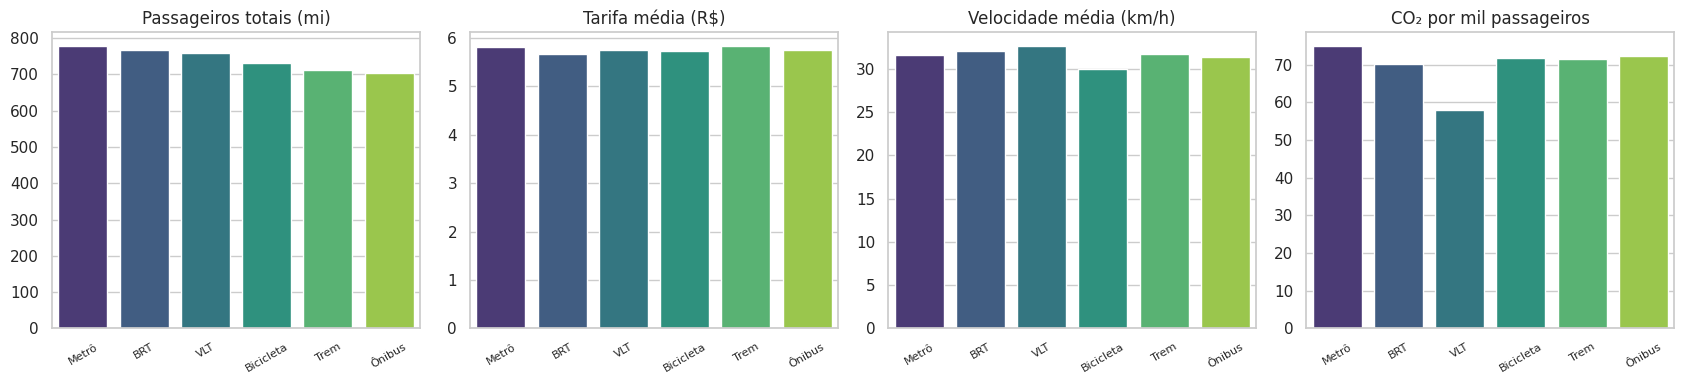

In [12]:
ordem = df.groupby("meio_transporte")["passageiros"].sum().sort_values(ascending=False).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
tit = {"passageiros": "Passageiros totais (mi)", "tarifa_media": "Tarifa média (R$)",
       "velocidade_media": "Velocidade média (km/h)", "co2_por_mil_pass": "CO₂ por mil passageiros"}
for ax, (c, t) in zip(axes, tit.items()):
    d = df.groupby("meio_transporte")[c].agg("sum" if c == "passageiros" else "mean").reindex(ordem)
    if c == "passageiros": d = d / 1e6
    sns.barplot(x=d.index, y=d.values, hue=d.index, legend=False, palette="viridis", ax=ax)
    ax.set(title=t, xlabel="", ylabel=""); ax.tick_params(axis="x", labelsize=8, rotation=30)
fig.tight_layout(); fig.savefig(IMG / "04_meios_transporte.png", dpi=130, bbox_inches="tight"); plt.show()

### 9.4 Congestionamento e sazonalidade

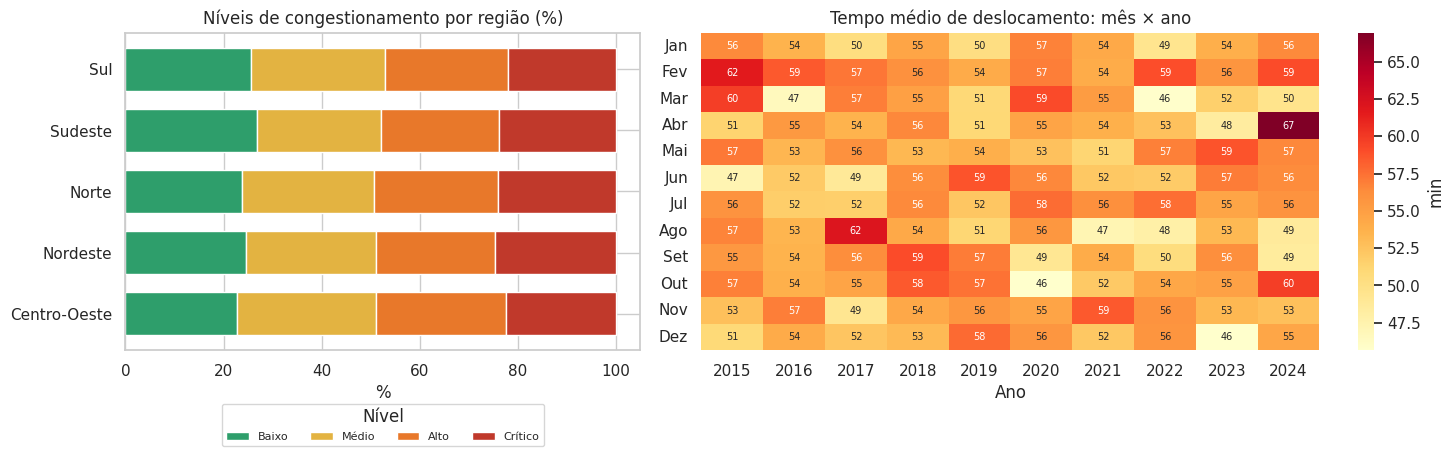

In [13]:
CORES = {"Baixo": "#2E9E6B", "Médio": "#E3B341", "Alto": "#E8782A", "Crítico": "#C0392B"}
ct = (pd.crosstab(df["regiao"], df["nivel_congestionamento"], normalize="index") * 100).reindex(columns=ORDEM)
hm = df.pivot_table(index="mes", columns="ano", values="tempo_medio_deslocamento", aggfunc="mean").rename(index=MESES)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1, 1.5]})
ct.plot(kind="barh", stacked=True, color=[CORES[n] for n in ORDEM], ax=axes[0], width=0.7)
axes[0].set(title="Níveis de congestionamento por região (%)", xlabel="%", ylabel="")
axes[0].legend(title="Nível", fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
sns.heatmap(hm, annot=True, fmt=".0f", cmap="YlOrRd", annot_kws={"size": 7}, cbar_kws={"label": "min"}, ax=axes[1])
axes[1].set(title="Tempo médio de deslocamento: mês × ano", xlabel="Ano", ylabel="")
axes[1].tick_params(axis="y", rotation=0)
fig.tight_layout(); fig.savefig(IMG / "05_congestionamento_sazonalidade.png", dpi=130, bbox_inches="tight"); plt.show()

In [14]:
display(df.groupby("nivel_congestionamento", observed=True)[["tempo_medio_deslocamento", "velocidade_media", "lotacao_media"]].mean().round(1))

,tempo_medio_deslocamento,velocidade_media,lotacao_media
nivel_congestionamento,,,
Baixo,54.1,31.3,69.6
Médio,54.0,32.2,70.7
Alto,55.1,31.6,70.2
Crítico,53.9,31.0,70.8


### 9.5 Correlação estatística

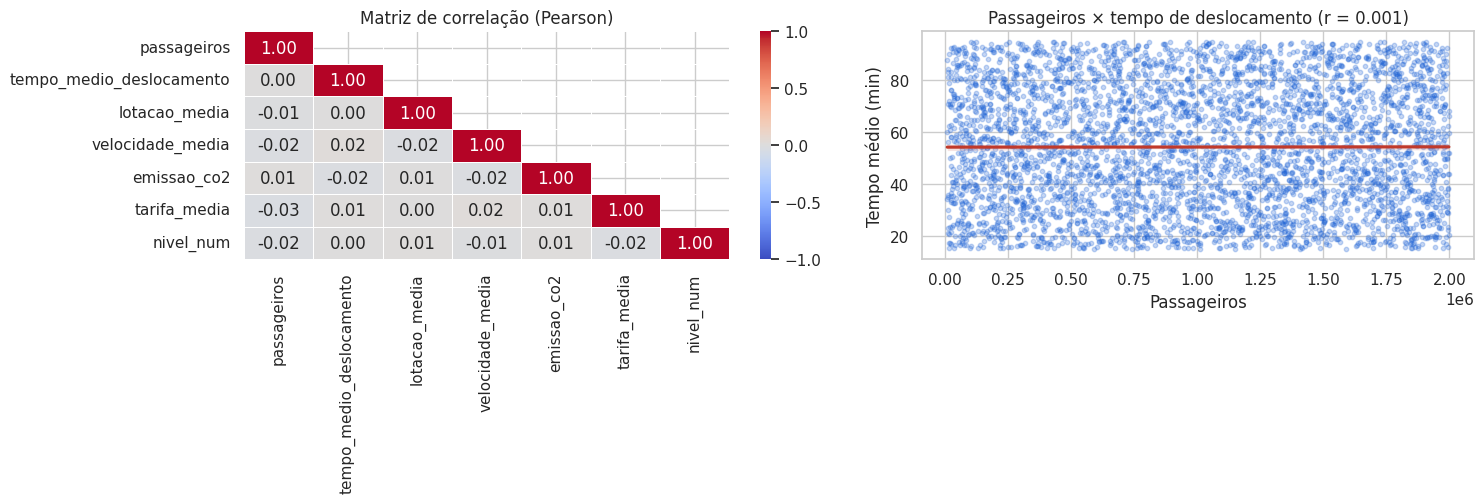

Pearson r = 0.0014 (p = 0.924) | Spearman rho = 0.0010 (p = 0.948)


In [15]:
cols = ["passageiros", "tempo_medio_deslocamento", "lotacao_media", "velocidade_media", "emissao_co2", "tarifa_media", "nivel_num"]
corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
r, p = stats.pearsonr(df["passageiros"], df["tempo_medio_deslocamento"])
rho, p_s = stats.spearmanr(df["passageiros"], df["tempo_medio_deslocamento"])
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.1, 1]})
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, linewidths=.5, ax=axes[0])
axes[0].set_title("Matriz de correlação (Pearson)")
sns.regplot(data=df, x="passageiros", y="tempo_medio_deslocamento", scatter_kws={"alpha": .25, "s": 10, "color": "#1E63D6"}, line_kws={"color": "#C0392B"}, ax=axes[1])
axes[1].set(title=f"Passageiros × tempo de deslocamento (r = {r:.3f})", xlabel="Passageiros", ylabel="Tempo médio (min)")
fig.tight_layout(); fig.savefig(IMG / "06_correlacoes.png", dpi=130, bbox_inches="tight"); plt.show()
print(f"Pearson r = {r:.4f} (p = {p:.3f}) | Spearman rho = {rho:.4f} (p = {p_s:.3f})")

## 10. Interpretação dos resultados

In [16]:
reg_t = df.groupby("regiao")["passageiros"].sum().sort_values(ascending=False)
reg_m = df.groupby("regiao")["passageiros"].mean().sort_values(ascending=False)
pres_c = df.groupby("cidade")["indice_pressao"].mean().sort_values(ascending=False)
pres_r = df.groupby("regiao")["indice_pressao"].mean().sort_values(ascending=False)
media_ano = df.groupby("ano")["passageiros"].sum()
anual_t = df.groupby("ano")["tempo_medio_deslocamento"].mean()
mod_t = df.groupby("meio_transporte")["passageiros"].sum().sort_values(ascending=False)
dif_tempo = df.groupby("nivel_congestionamento", observed=True)["tempo_medio_deslocamento"].mean()
off_pairs = corr.where(~mask & ~np.eye(len(cols), dtype=bool)).abs().stack()
n_cid_reg = df.groupby("regiao")["cidade"].nunique()

display(Markdown(f'''
**1. Cidades com maior fluxo.** {por_cidade.idxmax()} lidera ({por_cidade.max()/1e6:.1f} mi), seguida de {por_cidade.sort_values(ascending=False).index[1]} e {por_cidade.sort_values(ascending=False).index[2]}. As diferenças entre as cidades do topo são pequenas.

**2. Meio de transporte mais usado.** {mod_t.index[0]} ({mod_t.iloc[0]/mod_t.sum():.1%} do total), contra {mod_t.index[-1]} ({mod_t.iloc[-1]/mod_t.sum():.1%}) no menor. Os seis modais ficam entre {mod_t.min()/mod_t.sum():.1%} e {mod_t.max()/mod_t.sum():.1%}, ou seja, o uso é praticamente equilibrado.

**3. Tempo de deslocamento ao longo do tempo.** A média anual oscilou entre {anual_t.min():.1f} e {anual_t.max():.1f} min ({anual_t.iloc[0]:.1f} em {anual_t.index[0]} e {anual_t.iloc[-1]:.1f} em {anual_t.index[-1]}). **Não há tendência de aumento**; a variação é pequena frente à dispersão dos registros.

**4. Diferenças regionais.** {reg_t.index[0]} concentra {reg_t.iloc[0]/reg_t.sum():.0%} dos passageiros, mas tem {n_cid_reg[reg_t.index[0]]} cidades na base. Por cidade-mês, a região líder é {reg_m.index[0]} ({reg_m.iloc[0]/1e3:.0f} mil), com diferença pequena para as demais. O total bruto reflete o tamanho da amostra, e não uma desigualdade real.

**5. Pressão sobre o sistema.** A região com maior índice médio de pressão é {pres_r.index[0]} ({pres_r.iloc[0]:.3f}); entre as cidades, {pres_c.index[0]} ({pres_c.iloc[0]:.3f}). As diferenças entre as regiões estão na terceira casa decimal.

**6. Congestionamento vs. tempo.** O tempo médio em nível *Crítico* ({dif_tempo['Crítico']:.1f} min) é praticamente igual ao do nível *Baixo* ({dif_tempo['Baixo']:.1f} min), o que não seria esperado em dados reais.

**7. Correlação.** O maior coeficiente entre qualquer par de variáveis é |r| = {off_pairs.max():.3f}. Entre passageiros e tempo de deslocamento, r = {r:.3f} (p = {p:.2f}): **não há relação estatisticamente detectável**.
'''))


**1. Cidades com maior fluxo.** Rio de Janeiro lidera (131.1 mi), seguida de Juiz de Fora e Fortaleza. As diferenças entre as cidades do topo são pequenas.

**2. Meio de transporte mais usado.** Metrô (17.5% do total), contra Ônibus (15.8%) no menor. Os seis modais ficam entre 15.8% e 17.5%, ou seja, o uso é praticamente equilibrado.

**3. Tempo de deslocamento ao longo do tempo.** A média anual oscilou entre 53.1 e 55.6 min (55.2 em 2015 e 55.4 em 2024). **Não há tendência de aumento**; a variação é pequena frente à dispersão dos registros.

**4. Diferenças regionais.** Sudeste concentra 35% dos passageiros, mas tem 13 cidades na base. Por cidade-mês, a região líder é Sul (1039 mil), com diferença pequena para as demais. O total bruto reflete o tamanho da amostra, e não uma desigualdade real.

**5. Pressão sobre o sistema.** A região com maior índice médio de pressão é Norte (0.605); entre as cidades, Vitória (0.625). As diferenças entre as regiões estão na terceira casa decimal.

**6. Congestionamento vs. tempo.** O tempo médio em nível *Crítico* (53.9 min) é praticamente igual ao do nível *Baixo* (54.1 min), o que não seria esperado em dados reais.

**7. Correlação.** O maior coeficiente entre qualquer par de variáveis é |r| = 0.030. Entre passageiros e tempo de deslocamento, r = 0.001 (p = 0.92): **não há relação estatisticamente detectável**.


### Limitações
- **Base simulada:** as variáveis foram geradas de forma independente, então ausência de correlação e de tendência é um traço da simulação.
- **Sem horário:** a base é mensal, então não é possível identificar horários de pico. A sazonalidade mês × ano foi usada como substituto.
- **Sem população:** a pergunta *população × fluxo* exige cruzar com dados do IBGE por cidade, que não fazem parte da base.
- **Unidades:** velocidade, emissão e tarifa não trazem unidade; adotamos km/h e R$ por suposição.
- **Modal por linha:** o meio de transporte muda de um mês para outro na mesma cidade, então não há série contínua por modal.

## 11. Conclusão

In [17]:
n_reg = f"{len(df):,}".replace(",", ".")
display(Markdown(f'''
A análise percorreu o ciclo completo (leitura, limpeza, engenharia de atributos, exploração, KPIs, visualização e interpretação) sobre {n_reg} registros de {df['cidade'].nunique()} cidades.

- **Fluxo:** {por_cidade.idxmax()} é a cidade mais movimentada e {mod_t.index[0]} o modal predominante, mas as margens são estreitas.
- **Tempo:** sem tendência de piora ou melhora entre {anual_t.index[0]} e {anual_t.index[-1]}.
- **Regiões:** as diferenças nos totais vêm principalmente do número de cidades de cada região.
- **Correlação:** coeficientes próximos de zero em todos os pares; congestionamento não se associa a tempo, velocidade ou lotação.
- **Recomendação metodológica:** para tirar conclusões sobre política de mobilidade, seria preciso aplicar este mesmo fluxo a dados reais (por exemplo, pesquisas de origem-destino e dados do IBGE), incluindo horário e população.
'''))


A análise percorreu o ciclo completo (leitura, limpeza, engenharia de atributos, exploração, KPIs, visualização e interpretação) sobre 4.440 registros de 37 cidades.

- **Fluxo:** Rio de Janeiro é a cidade mais movimentada e Metrô o modal predominante, mas as margens são estreitas.
- **Tempo:** sem tendência de piora ou melhora entre 2015 e 2024.
- **Regiões:** as diferenças nos totais vêm principalmente do número de cidades de cada região.
- **Correlação:** coeficientes próximos de zero em todos os pares; congestionamento não se associa a tempo, velocidade ou lotação.
- **Recomendação metodológica:** para tirar conclusões sobre política de mobilidade, seria preciso aplicar este mesmo fluxo a dados reais (por exemplo, pesquisas de origem-destino e dados do IBGE), incluindo horário e população.
